## CitySeer: Métricas Configuracionais do Espaço Urbano

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [1]:
from __future__ import annotations

# ============================================================================
# Standard library
# ============================================================================
import joblib
import os
import pathlib
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple, Type

# ============================================================================
# Third-party libraries
# ============================================================================
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels
import xgboost as xgb
from matplotlib_scalebar import scalebar
from scipy.stats import hmean
from shapely.geometry import Polygon
from shapely.ops import unary_union
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler, minmax_scale
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant, maybe_unwrap_results


sns.set_theme(style="dark")
sns.set_context("paper")

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
MAIN_DATA = Path(os.environ.get('DB_FOLDER'))

FOLDER = os.environ.get('OUT_FOLDER')

DATABASE = Path(FOLDER)

OUT_DIR = Path(FOLDER) / 'B/cityseer'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
OUT_PARQUET    = (
    OUT_DIR
    / f"accessibilities.parquet"
    )

access = pd.read_parquet(
    OUT_PARQUET
)

In [5]:
OUT_PARQUET    = (
    OUT_DIR
    / f"nodes.parquet"
    )

nodes = gpd.read_parquet(
    OUT_PARQUET
)

In [6]:
OUT_PARQUET    = (
    OUT_DIR
    / f"centralities.parquet"
    )
centralities = pd.read_parquet(
    OUT_PARQUET
)

In [7]:
slicers = [
    ('income', 'public', 'shortest', 1500),
    ('income', 'private', 'shortest', 1500),
    ('income', 'walk', 'shortest', 1500),
    ('households', 'public', 'shortest', 1500),
    ('households', 'private', 'shortest', 1500),
    ('households', 'walk', 'shortest', 1500),
]

db = []
for slice in slicers:
    df = centralities.xs(slice, level=('weight', 'mode', 'path', 'radius'))
    df = df[['betweenness_beta', 'harmonic', 'beta']]
    df.columns = [f"{slice[0]}_{col}_{slice[1]}" for col in df.columns]

    db.append(df.copy())

db = pd.concat(db, axis=1)

retail = access.xs(('yes', 250), level=('weight', 'radius')).filter(like='access')
hill = access.xs(('yes', 500), level=('weight', 'radius')).filter(like='hill')

db = pd.concat([
    retail,
    hill,
    db,
        
], axis='columns')

db = nodes[['x', 'y', 'primal_edge']].merge(
    db,
    left_index=True,
    right_index=True,
)


In [8]:
db_folder = os.environ.get('DB_FOLDER')
db_folder = pathlib.Path(db_folder) / 'beaga'

inpath = db_folder / 'zoning/ZONAS_Lei_7166-96.zip'
old_zoning = gpd.read_file(inpath)

old_zoning = old_zoning.loc[~old_zoning.SIGLA_ZONE.isin([
    'ZEPIL', 'ZEJAT', 'ZEIS1', 'ZEIS2', 'ZEIS3',
    'ZPAM', 'ZP1', 'ZP2', 'ZP3', 'ZE',
    ])]

db = db.sjoin_nearest(
    old_zoning[['geometry']],
    max_distance=25,
).drop(columns=['index_right'])

db = db.loc[~db.index.duplicated()]

In [9]:
inpath =  DATABASE / 'A/entorno.gpkg'
surroundings = gpd.read_file(inpath).to_crs(31983)

db = db.sjoin(surroundings, how="left", predicate="intersects").drop(columns=['index_right'])
db = db.loc[~db.index.duplicated()].drop(columns='id_setor_censitario')

In [10]:
inpath =  DATABASE / 'A/crime_by_borough.gpkg'
crime = gpd.read_file(inpath)

db = db.sjoin(
    crime[['crime_rate', 'geometry']],
    how="left", predicate="intersects").drop(columns=['index_right'])
db = db.loc[~db.index.duplicated()]

In [11]:
inpath =  DATABASE / 'A/slopes_by_hex.parquet'
slopes = gpd.read_parquet(inpath).dropna().query("aperture == 11")

slopes_by_segment = gpd.sjoin(
    db,
    slopes[['median', 'geometry']],
    how="left", predicate="intersects").drop(columns=['index_right']
).reset_index(names='node_id')

slopes_by_segment = slopes_by_segment.groupby('node_id').agg({'median': hmean})
slopes_by_segment = slopes_by_segment.rename(columns={'median': 'slope'})

In [12]:
db = db.merge(
    slopes_by_segment,
    left_index=True,
    right_index=True,
    how='left'
)

In [13]:
db = db.fillna(0)

# Variable Preparation

In [14]:
def fit_zscores(df: pd.DataFrame, cols: Sequence[str]):
    """
    Fit a z-score transformer on `cols` of df and return:
      - Z: DataFrame with z-scored columns (same index/columns)
      - scaler: fitted StandardScaler (has mean_ and scale_)
      - meta: tidy table with mean and std for documentation
    """
    X = df.loc[:, cols].astype(float)
    scaler = StandardScaler(with_mean=True, with_std=True)
    Z = pd.DataFrame(scaler.fit_transform(X), columns=cols, index=df.index)

    meta = pd.DataFrame(
        {"mean": scaler.mean_, "std": scaler.scale_}, index=cols
    )
    return Z, scaler, meta

def apply_zscores(df: pd.DataFrame, cols: Sequence[str],
                  scaler: StandardScaler) -> pd.DataFrame:
    """Apply a fitted scaler to new data with the same columns."""
    X = df.loc[:, cols].astype(float)
    Z = pd.DataFrame(scaler.transform(X), columns=cols, index=df.index)
    return Z

def invert_zscores(Z: pd.DataFrame, scaler: StandardScaler) -> pd.DataFrame:
    """Return variables to their original units."""
    X = pd.DataFrame(
        scaler.inverse_transform(Z.values),
        columns=Z.columns, index=Z.index
    )
    return X


In [15]:
# Transform target variable
# Log-transform to reduce skewness
y_name = 'accessibility'
y, y_scaler, y_meta = fit_zscores(
    db.assign(accessibility=np.log1p(db[y_name])),
    [y_name]
    )

# Persist the transformer for later reuse/reversal
joblib.dump(y_scaler, "model_data/y_zscore_scaler.joblib")
y_meta.to_csv("model_data/y_zscore_params.csv", index=True)  # human-readable record)

# Fit scaler on predictors
x_names = db.iloc[:, 4:].columns.tolist()
X, x_scaler, x_meta = fit_zscores(db, x_names)

# Again, persist the transformer         
joblib.dump(x_scaler, "model_data/X_zscore_scaler.joblib")
x_meta.to_csv("model_data/X_zscore_params.csv", index=True)  # human-readable record)

# Regression and Diagnostics

In [16]:
X = X.drop(columns=X.filter(like='harmonic').columns)
#X = X.drop(columns=X.filter(like='walk').columns)
X = X.drop(columns=X.filter(like='private').columns)
X = X.drop(columns=[
    'hill_q0', 'hill_q2',
    'households_betweenness_beta_public',
    'income_betweenness_beta_public',
    'households_beta_walk',
    'income_beta_walk',
    ])

X_names = X.columns.tolist()

In [17]:
df = pd.concat([y, X], axis=1)
df['has_retail'] = np.where(
    df.accessibility > 0, 1, 0
)
df.head()

,accessibility,hill_q1,income_beta_public,income_betweenness_beta_walk,households_beta_public,households_betweenness_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope,has_retail
257609528_5000025481_k0,-0.96,-0.28,-0.58,-0.61,-0.16,-0.77,-1.86,-2.18,-0.97,-2.87,-0.32,-0.85,0
257609528_316683844_k0,-0.61,-0.74,-0.54,-0.32,0.10,0.43,-1.86,-2.18,-0.97,-2.87,-0.32,-1.07,0
257609528_316683843_k0,-0.91,-0.00,-0.58,-0.34,-0.14,0.40,-1.86,-2.18,-0.97,-2.87,-0.32,-0.88,0
316683843_316761921_k0,-1.31,-0.75,-0.67,-0.58,-0.60,-0.60,-0.84,0.52,-0.97,-1.22,-0.32,-0.66,0
316683843_316761938_k0,-0.90,0.73,-0.61,-0.32,-0.30,0.53,-0.84,0.52,-0.97,-1.22,-0.32,-0.84,0


## Exploring

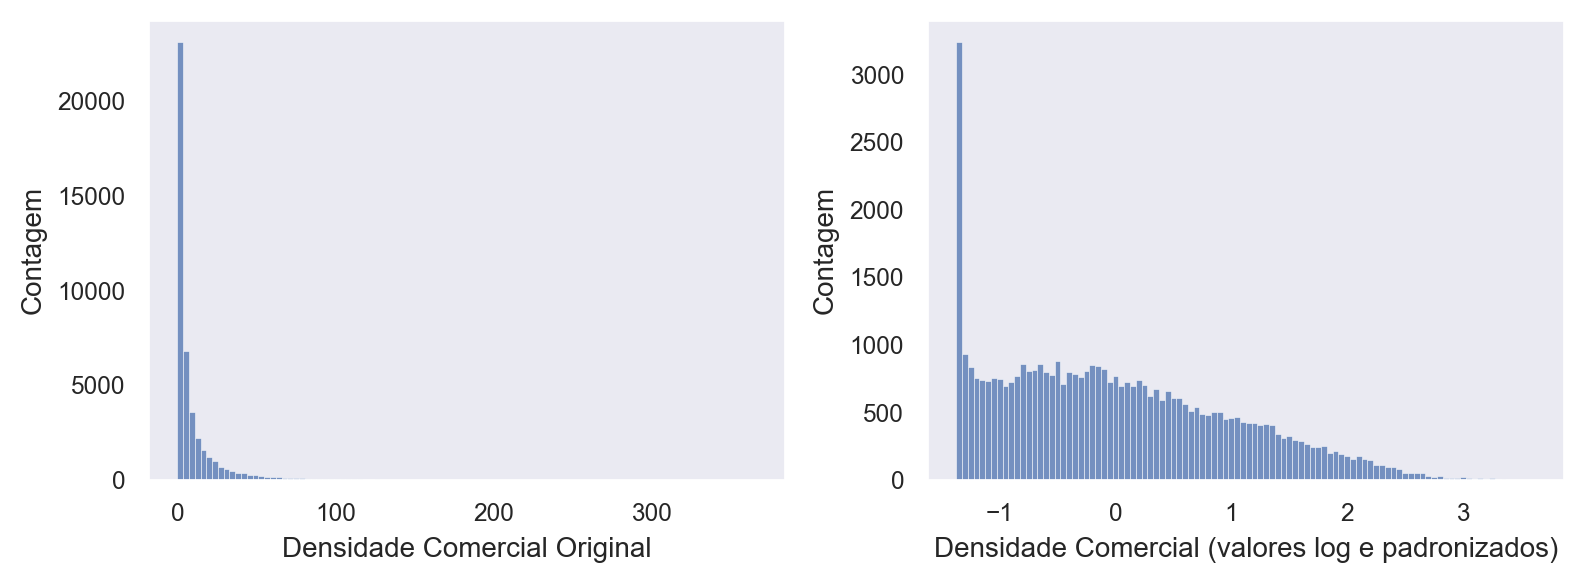

In [18]:
f, axes = plt.subplots(figsize=(8, 3), ncols=2)

sns.histplot(
    ax=axes[0],
    data=db['accessibility'],
    bins=100,
)
axes[0].set_xlabel("Densidade Comercial Original", fontsize=10)
axes[0].set_ylabel("Contagem", fontsize=10)


sns.histplot(
    ax=axes[1],
    data=y['accessibility'],
    bins=100,
)
axes[1].set_xlabel("Densidade Comercial (valores log e padronizados)", fontsize=10)
axes[1].set_ylabel("Contagem", fontsize=10)

plt.tight_layout()
plt.show()

In [19]:
df.corr(method='spearman')

,accessibility,hill_q1,income_beta_public,income_betweenness_beta_walk,households_beta_public,households_betweenness_beta_walk,bueiros,obstaculo_calcada,rampa_cadeirante,com_arvores,crime_rate,slope,has_retail
accessibility,1.00,0.50,0.74,0.57,0.56,0.30,0.18,-0.15,0.51,0.44,0.40,-0.11,0.86
hill_q1,0.50,1.00,0.51,0.41,0.48,0.32,0.05,0.03,0.31,0.15,0.15,-0.21,0.42
income_beta_public,0.74,0.51,1.00,0.60,0.85,0.34,0.25,-0.15,0.52,0.36,0.37,-0.15,0.63
income_betweenness_beta_walk,0.57,0.41,0.60,1.00,0.57,0.89,0.13,-0.07,0.32,0.25,0.19,-0.10,0.47
households_beta_public,0.56,0.48,0.85,0.57,1.00,0.45,0.18,-0.10,0.40,0.21,0.23,-0.19,0.45
households_betweenness_beta_walk,0.30,0.32,0.34,0.89,0.45,1.00,0.03,0.04,0.11,0.04,0.00,-0.05,0.22
bueiros,0.18,0.05,0.25,0.13,0.18,0.03,1.00,-0.06,0.26,0.23,0.24,-0.09,0.13
obstaculo_calcada,-0.15,0.03,-0.15,-0.07,-0.10,0.04,-0.06,1.00,-0.29,-0.05,-0.17,0.15,-0.14
rampa_cadeirante,0.51,0.31,0.52,0.32,0.40,0.11,0.26,-0.29,1.00,0.48,0.42,-0.26,0.44
com_arvores,0.44,0.15,0.36,0.25,0.21,0.04,0.23,-0.05,0.48,1.00,0.34,-0.06,0.36


C:\Users\brand\AppData\Local\Temp\ipykernel_6400\1394363231.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


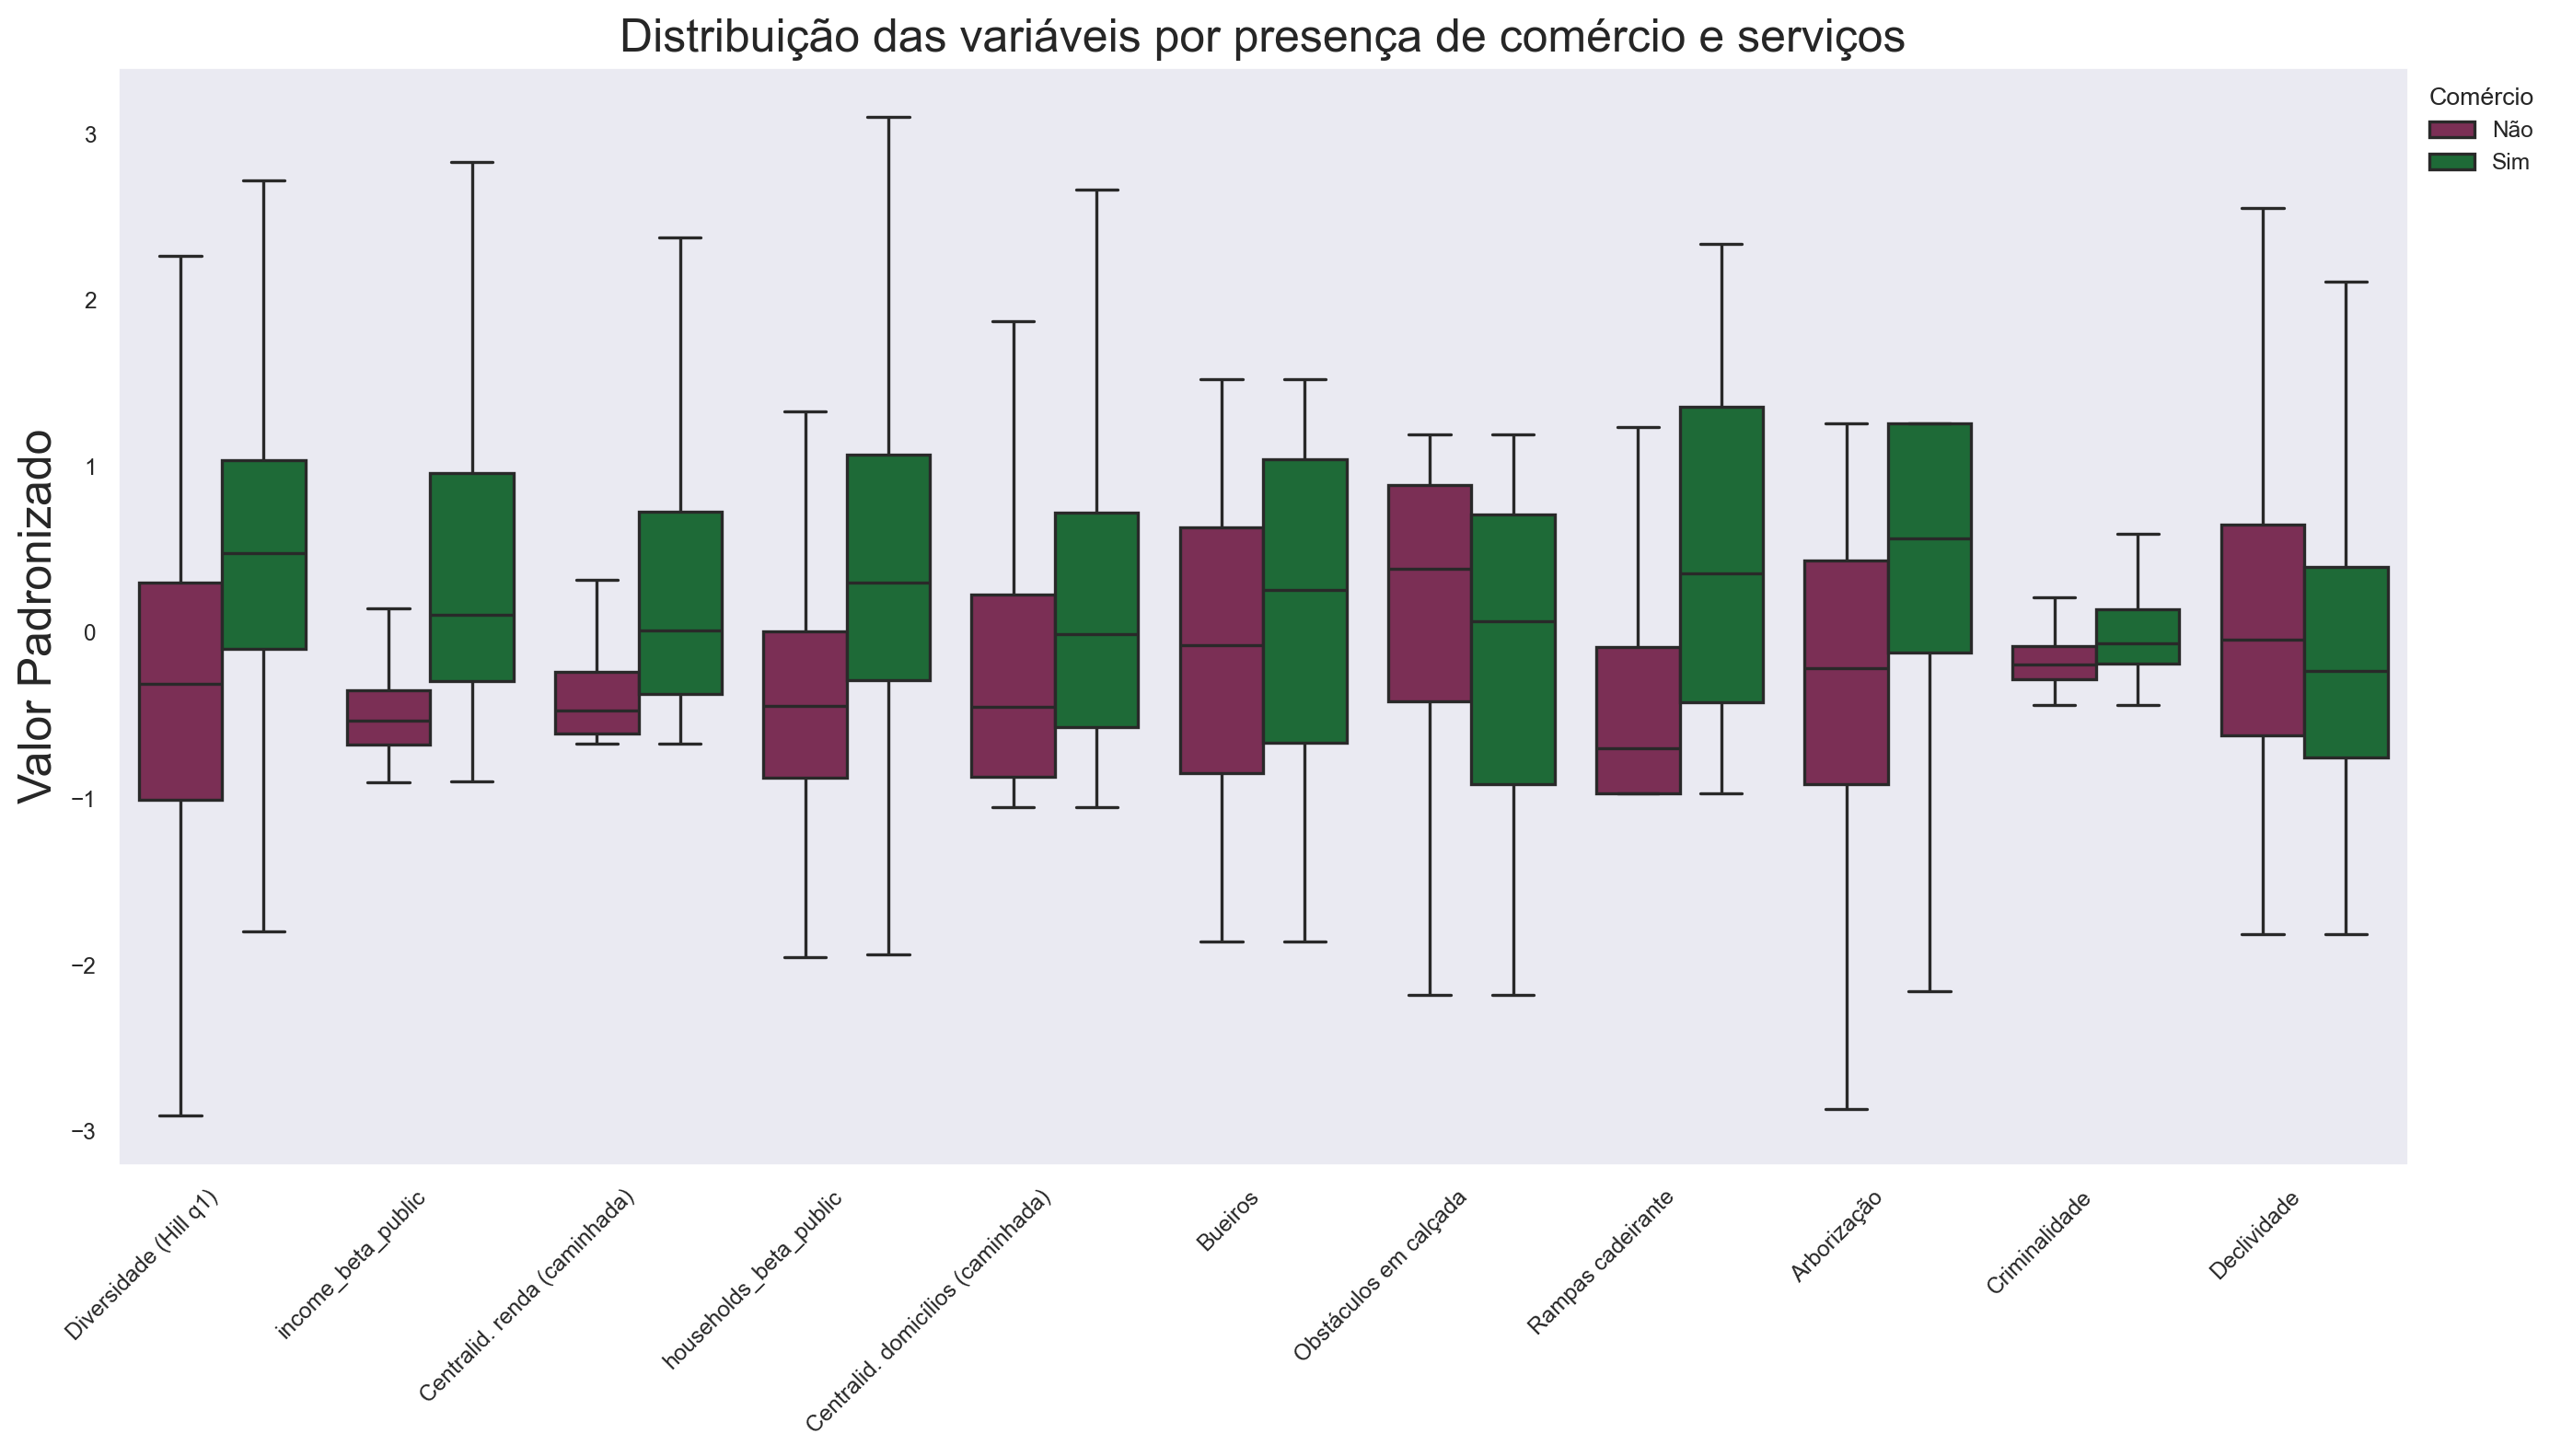

In [20]:
df_long = df.drop(columns=['accessibility']).melt(
    id_vars="has_retail",
    var_name="variable",
    value_name="value"
).replace({"has_retail": {0: "Não", 1: "Sim"}})

rename_dict = {
    "hill_q1": "Diversidade (Hill q1)",
    "income_harmonic_public": "Acess. renda (TP)",
    "income_betweenness_beta_walk": "Centralid. renda (caminhada)",
    "households_harmonic_public": "Acess. domicílios (TP)",
    "households_betweenness_beta_walk": "Centralid. domicílios (caminhada)",
    "bueiros": "Bueiros",
    "obstaculo_calcada": "Obstáculos em calçada",
    "rampa_cadeirante": "Rampas cadeirante",
    "com_arvores": "Arborização",
    "crime_rate": "Criminalidade",
    "slope": "Declividade"
}
df_long = df_long.replace({'variable': rename_dict})

# --- Plot ---
plt.figure(figsize=(14, 8))

palette = {
    'Não': "#882255",   # azul — sem comércio
    'Sim': "#117733"    # laranja — com comércio
}

ax = sns.boxplot(
    data=df_long,
    x="variable",
    y="value",
    hue="has_retail",
    showfliers=False,
    linewidth=1.2,
    palette=palette,
)

# --- Eixo x mais limpo ---
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Valor Padronizado", fontsize=18)

# --- Título e legendas ---
ax.legend(
    title="Comércio",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    frameon=False
)
plt.title("Distribuição das variáveis por presença de comércio e serviços", fontsize=18)

# --- Margens e layout ---
plt.tight_layout()
plt.show()


## Base Regression

In [21]:
model = OLS(y, add_constant(X))
ols = model.fit()

In [22]:
style_talk = 'seaborn-talk'    #refer to plt.style.available

class LinearRegDiagnostic():
    """
    Diagnostic plots to identify potential problems in a linear regression fit.
    Mainly,
        a. non-linearity of data
        b. Correlation of error terms
        c. non-constant variance
        d. outliers
        e. high-leverage points
        f. collinearity

    Authors:
        Prajwal Kafle (p33ajkafle@gmail.com, where 3 = r)
        Does not come with any sort of warranty.
        Please test the code one your end before using.

        Matt Spinelli (m3spinelli@gmail.com, where 3 = r)
        (1) Fixed incorrect annotation of the top most extreme residuals in
            the Residuals vs Fitted and, especially, the Normal Q-Q plots.
        (2) Changed Residuals vs Leverage plot to match closer the y-axis
            range shown in the equivalent plot in the R package ggfortify.
        (3) Added horizontal line at y=0 in Residuals vs Leverage plot to
            match the plots in R package ggfortify and base R.
        (4) Added option for placing a vertical guideline on the Residuals
            vs Leverage plot using the rule of thumb of h = 2p/n to denote
            high leverage (high_leverage_threshold=True).
        (5) Added two more ways to compute the Cook's Distance (D) threshold:
            * 'baseR': D > 1 and D > 0.5 (default)
            * 'convention': D > 4/n
            * 'dof': D > 4 / (n - k - 1)
        (6) Fixed class name to conform to Pascal casing convention
        (7) Fixed Residuals vs Leverage legend to work with loc='best'
    """

    def __init__(self,
                 results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
        """
        For a linear regression model, generates following diagnostic plots:

        a. residual
        b. qq
        c. scale location and
        d. leverage

        and a table

        e. vif

        Args:
            results (Type[statsmodels.regression.linear_model.RegressionResultsWrapper]):
                must be instance of statsmodels.regression.linear_model object

        Raises:
            TypeError: if instance does not belong to above object

        Example:
        >>> import numpy as np
        >>> import pandas as pd
        >>> import statsmodels.formula.api as smf
        >>> x = np.linspace(-np.pi, np.pi, 100)
        >>> y = 3*x + 8 + np.random.normal(0,1, 100)
        >>> df = pd.DataFrame({'x':x, 'y':y})
        >>> res = smf.ols(formula= "y ~ x", data=df).fit()
        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls(plot_context="seaborn-v0_8-paper")

        In case you do not need all plots you can also independently make an individual plot/table
        in following ways

        >>> cls = Linear_Reg_Diagnostic(res)
        >>> cls.residual_plot()
        >>> cls.qq_plot()
        >>> cls.scale_location_plot()
        >>> cls.leverage_plot()
        >>> cls.vif_table()
        """

        if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
            raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")

        self.results = maybe_unwrap_results(results)

        self.y_true = self.results.model.endog
        self.y_predict = self.results.fittedvalues
        self.xvar = self.results.model.exog
        self.xvar_names = self.results.model.exog_names

        self.residual = np.array(self.results.resid)
        influence = self.results.get_influence()
        self.residual_norm = influence.resid_studentized_internal
        self.leverage = influence.hat_matrix_diag
        self.cooks_distance = influence.cooks_distance[0]
        self.nparams = len(self.results.params)
        self.nresids = len(self.residual_norm)

    def __call__(self, plot_context='seaborn-v0_8-paper', **kwargs):
        # print(plt.style.available)
        # GH#9157
        if plot_context not in plt.style.available:
            plot_context = 'default'
        with plt.style.context(plot_context):
            fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
            self.residual_plot(ax=ax[0,0])
            self.qq_plot(ax=ax[0,1])
            self.scale_location_plot(ax=ax[1,0])
            self.leverage_plot(
                ax=ax[1,1],
                high_leverage_threshold = kwargs.get('high_leverage_threshold'),
                cooks_threshold = kwargs.get('cooks_threshold'))
            plt.show()

        return self.vif_table(), fig, ax,

    def residual_plot(self, ax=None):
        """
        Residual vs Fitted Plot

        Graphical tool to identify non-linearity.
        (Roughly) Horizontal red line is an indicator that the residual has a linear pattern
        """
        if ax is None:
            fig, ax = plt.subplots()

        sns.residplot(
            x=self.y_predict,
            y=self.residual,
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        residual_abs = np.abs(self.residual)
        abs_resid = np.flip(np.argsort(residual_abs), 0)
        abs_resid_top_3 = abs_resid[:3]
        for i in abs_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], self.residual[i]),
                color='C3')

        ax.set_title('Residuals vs Fitted', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel('Residuals')
        return ax

    def qq_plot(self, ax=None):
        """
        Standarized Residual vs Theoretical Quantile plot

        Used to visually check if residuals are normally distributed.
        Points spread along the diagonal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        QQ = ProbPlot(self.residual_norm)
        fig = QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)

        # annotations
        abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
        abs_norm_resid_top_3 = abs_norm_resid[:3]
        for i, x, y in self.__qq_top_resid(QQ.theoretical_quantiles, abs_norm_resid_top_3):
            ax.annotate(
                i,
                xy=(x, y),
                ha='right',
                color='C3')

        ax.set_title('Normal Q-Q', fontweight="bold")
        ax.set_xlabel('Theoretical Quantiles')
        ax.set_ylabel('Standardized Residuals')
        return ax

    def scale_location_plot(self, ax=None):
        """
        Sqrt(Standarized Residual) vs Fitted values plot

        Used to check homoscedasticity of the residuals.
        Horizontal line will suggest so.
        """
        if ax is None:
            fig, ax = plt.subplots()

        residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))

        ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
        sns.regplot(
            x=self.y_predict,
            y=residual_norm_abs_sqrt,
            scatter=False, ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
        abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
        for i in abs_sq_norm_resid_top_3:
            ax.annotate(
                i,
                xy=(self.y_predict[i], residual_norm_abs_sqrt[i]),
                color='C3')

        ax.set_title('Scale-Location', fontweight="bold")
        ax.set_xlabel('Fitted values')
        ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
        return ax

    def leverage_plot(self, ax=None, high_leverage_threshold=False, cooks_threshold='baseR'):
        """
        Residual vs Leverage plot

        Points falling outside Cook's distance curves are considered observation that can sway the fit
        aka are influential.
        Good to have none outside the curves.
        """
        if ax is None:
            fig, ax = plt.subplots()

        ax.scatter(
            self.leverage,
            self.residual_norm,
            alpha=0.5);

        sns.regplot(
            x=self.leverage,
            y=self.residual_norm,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8},
            ax=ax)

        # annotations
        leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(
                i,
                xy=(self.leverage[i], self.residual_norm[i]),
                color = 'C3')

        factors = []
        if cooks_threshold == 'baseR' or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == 'convention':
            factors = [4/self.nresids]
        elif cooks_threshold == 'dof':
            factors = [4/ (self.nresids - self.nparams)]
        else:
            raise ValueError("threshold_method must be one of the following: 'convention', 'dof', or 'baseR' (default)")
        for i, factor in enumerate(factors):
            label = "Cook's distance" if i == 0 else None
            xtemp, ytemp = self.__cooks_dist_line(factor)
            ax.plot(xtemp, ytemp, label=label, lw=1.25, ls='--', color='red')
            ax.plot(xtemp, np.negative(ytemp), lw=1.25, ls='--', color='red')

        if high_leverage_threshold:
            high_leverage = 2 * self.nparams / self.nresids
            if max(self.leverage) > high_leverage:
                ax.axvline(high_leverage, label='High leverage', ls='-.', color='purple', lw=1)

        ax.axhline(0, ls='dotted', color='black', lw=1.25)
        ax.set_xlim(0, max(self.leverage)+0.01)
        ax.set_ylim(min(self.residual_norm)-0.1, max(self.residual_norm)+0.1)
        ax.set_title('Residuals vs Leverage', fontweight="bold")
        ax.set_xlabel('Leverage')
        ax.set_ylabel('Standardized Residuals')
        plt.legend(loc='best')
        return ax

    def vif_table(self):
        """
        VIF table

        VIF, the variance inflation factor, is a measure of multicollinearity.
        VIF > 5 for a variable indicates that it is highly collinear with the
        other input variables.
        """
        vif_df = pd.DataFrame()
        vif_df["Features"] = self.xvar_names
        vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]

        return (vif_df
                .sort_values("VIF Factor")
                .round(2))


    def __cooks_dist_line(self, factor):
        """
        Helper function for plotting Cook's distance curves
        """
        p = self.nparams
        formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
        x = np.linspace(0.001, max(self.leverage), 50)
        y = formula(x)
        return x, y


    def __qq_top_resid(self, quantiles, top_residual_indices):
        """
        Helper generator function yielding the index and coordinates
        """
        offset = 0
        quant_index = 0
        previous_is_negative = None
        for resid_index in top_residual_indices:
            y = self.residual_norm[resid_index]
            is_negative = y < 0
            if previous_is_negative == None or previous_is_negative == is_negative:
                offset += 1
            else:
                quant_index -= offset
            x = quantiles[quant_index] if is_negative else np.flip(quantiles, 0)[quant_index]
            quant_index += 1
            previous_is_negative = is_negative
            yield resid_index, x, y


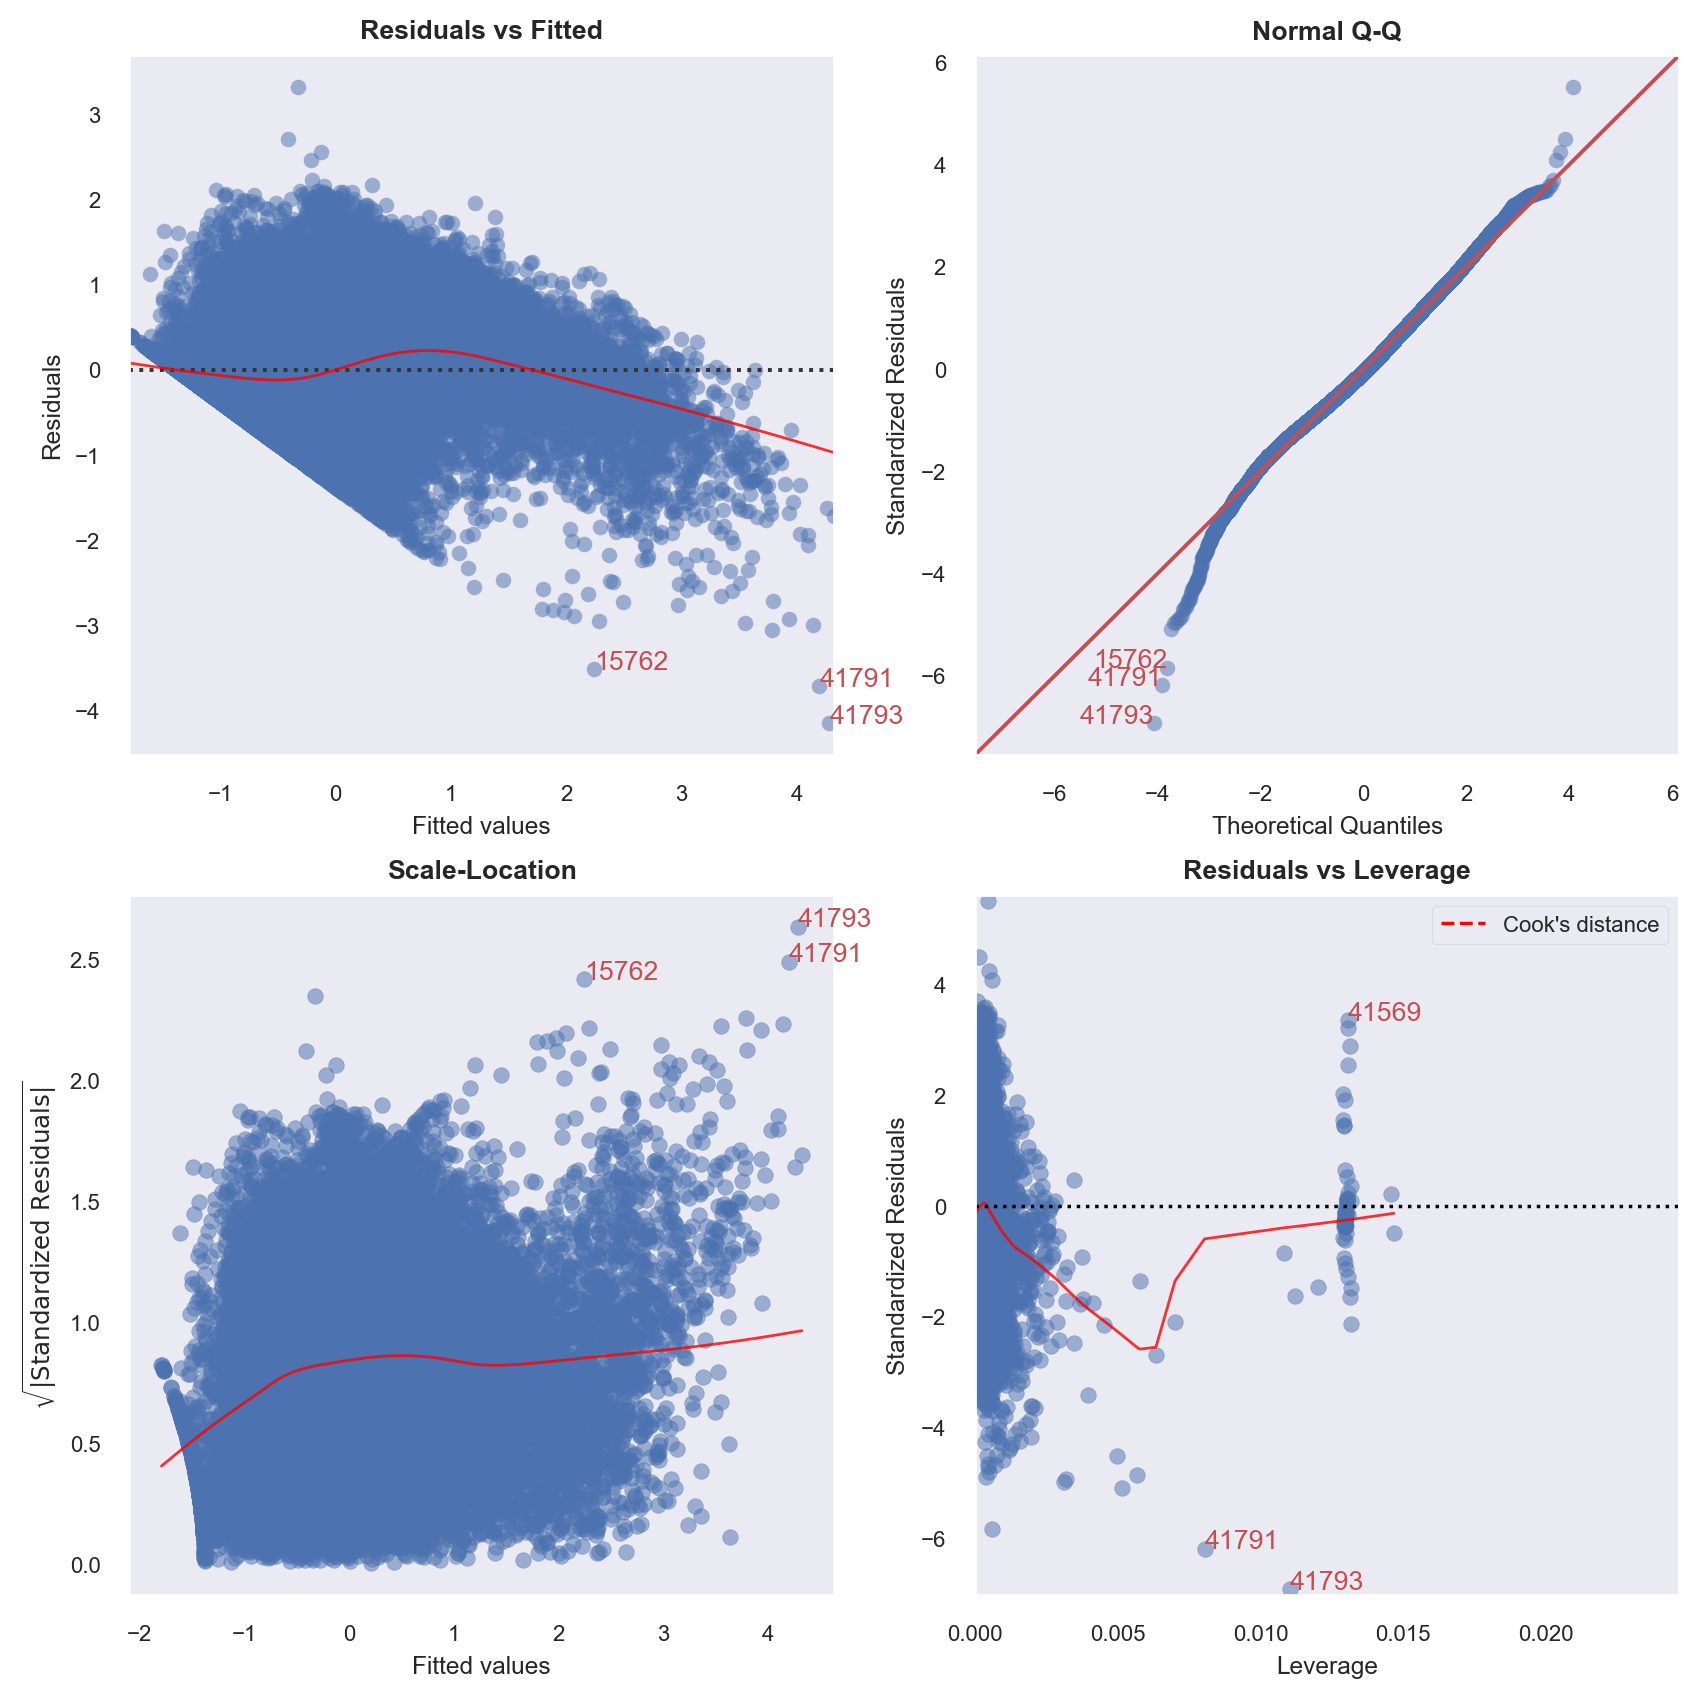

In [23]:
# Alternatively, all diagnostics can be generated in one go as follows.
# Fig and ax can be used to modify axes or plot properties after the fact.
cls = LinearRegDiagnostic(ols)
vif, fig, ax = cls()

In [24]:
vif

,Features,VIF Factor
0,const,1.00
10,crime_rate,1.08
11,slope,1.14
6,bueiros,1.16
7,obstaculo_calcada,1.32
9,com_arvores,1.42
1,hill_q1,1.43
8,rampa_cadeirante,1.99
5,households_betweenness_beta_walk,3.15
3,income_betweenness_beta_walk,4.43


In [25]:
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          accessibility   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     7057.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:04:43   Log-Likelihood:                -40233.
No. Observations:               44140   AIC:                         8.049e+04
Df Residuals:                   44128   BIC:                         8.059e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             8.327e-17      0.003   2.91e-14      1.000      -0.006       0.006
hill_q1                              0.3133      0.003     91.441      0.000       0.307       0.320
income_beta_public                   0.6230      0.008     74.614      0.000       0.607       0.639
income_betweenness_beta_walk         0.1056      0.006     17.510      0.000       0.094       0.117
households_beta_public              -0.2002      0.007    -28.099      0.000      -0.214      -0.186
households_betweenness_beta_walk     0.0076      0.005      1.490      0.136      -0.002       0.018
bueiros                             -0.0452      0.003    -14.675      0.000      -0.051      -0.039
obstaculo_calcada                    0.0033      0.003      0.994      0.320      -0.003       0.010
rampa_cadeirante                     0.1265      0.004     31.323      0.000       0.119       0.134
com_arvores                          0.1412      0.003     41.313      0.000       0.135       0.148
crime_rate                          -0.0160      0.003     -5.394      0.000      -0.022      -0.010
slope                                0.0465      0.003     15.172      0.000       0.040       0.052
==============================================================================
Omnibus:                      415.135   Durbin-Watson:                   0.783
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              594.784
Skew:                           0.114   Prob(JB):                    6.99e-130
Kurtosis:                       3.521   Cond. No.                         7.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# XGBoost and GEOShapley

In [26]:
# -*- coding: utf-8 -*-
"""
XGBoost + Optuna with Bootstrap and Nested Outer CV (single inner split)

- Stage 1 (tree): high learning rate chosen by timing; Optuna search on a
  single deterministic validation split inside each outer fold, with
  XGBoostPruningCallback (iteration-level) and time-boxed trials.
- Stage 2 (boosting): low learning rate; determine n_estimators on the
  same split via early stopping; final fit on the entire outer-training
  set (no early stopping).
- Target is modeled on log1p-standardized scale; predictions are returned
  to the original scale using a smearing correction.
- Randomness handled by np.random.default_rng with deterministic
  sub-seeds per bootstrap replicate.
- Optional Optuna diagnostic plots and tqdm progress bars.
- Variable names are intentionally verbose for clarity.

Author: (your name)
"""

from __future__ import annotations

import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple, Union

import numpy as np
import optuna
import optuna.visualization as optuna_vis
import pandas as pd
import xgboost as xgb
from sklearn.base import BaseEstimator
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split

try:
    from tqdm.auto import tqdm
except Exception:  # tqdm is optional
    def tqdm(x, **kwargs):  # fallback noop
        return x

# ===================== 0. Global settings =================================

warnings.filterwarnings("ignore", category=UserWarning)
# Make Optuna reasonably talkative during development
optuna.logging.set_verbosity(optuna.logging.INFO)

ArrayLike = Union[np.ndarray, pd.Series, pd.DataFrame]

# ===================== 1. Configuration dataclasses =======================

@dataclass
class OptimizationConfig:
    """Hyperparameter optimization and training controls."""
    timeout_seconds: int = 90
    early_stopping_rounds: int = 50
    max_num_boost_round: int = 10_000
    random_seed: int = 42
    stage2_low_learning_rate: float = 0.01
    high_lr_timing_low_seconds: float = 2.0
    high_lr_timing_high_seconds: float = 6.0
    high_lr_candidates: Tuple[float, ...] = (0.8, 0.5, 0.3, 0.2, 0.1)


@dataclass
class ValidationConfig:
    """Validation, partitioning, bootstrap, and UX settings."""
    num_bootstrap_iterations: int = 50
    num_outer_cv_folds: int = 5
    test_size_fraction: float = 0.2
    confidence_alpha: float = 0.05
    random_seed: int = 42
    inner_validation_fraction: float = 0.2  # single split inside outer-train
    use_progress_bars: bool = True


@dataclass
class PlotConfig:
    """Optional Optuna plots."""
    save_artifacts: bool = False
    output_directory: Union[str, Path] = "optuna_plots"
    save_png_if_possible: bool = True  # requires 'kaleido'

# ===================== 2. Outcome dataclass ===============================

@dataclass
class NestedBootstrapOutcome:
    """Complete outcome of the experiment."""
    test_rmse: float
    test_ci: Tuple[float, float]
    outer_scores: pd.DataFrame
    best_params_per_fold: List[Dict]
    final_best_params: Dict
    bootstrap_models: List[BaseEstimator]
    learning_curves: List[Dict]
    trials_summary: Optional[pd.DataFrame] = None
    optuna_plot_paths: Optional[List[Dict]] = None

# ===================== 3. Utility functions ===============================

def root_mean_squared_error(
    y_true: ArrayLike, y_pred: ArrayLike
) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bootstrap_percentile_ci(
    values: np.ndarray, alpha: float = 0.05
) -> Tuple[float, float]:
    low = 100.0 * (alpha / 2.0)
    high = 100.0 * (1.0 - alpha / 2.0)
    return (np.percentile(values, low), np.percentile(values, high))

def make_kfold_for_regression(
    num_splits: int, random_seed: int
) -> KFold:
    return KFold(n_splits=num_splits, shuffle=True, random_state=random_seed)

# ===================== 4. Log + smearing wrapper ==========================

class LogTransformedRegressor(BaseEstimator):
    """
    Wraps a base estimator trained on log1p-standardized targets and
    returns predictions on the original scale using a smearing factor.
    """

    def __init__(
        self,
        base_estimator: BaseEstimator,
        target_log_scaled_mean: float,
        target_log_scaled_std: float,
    ):
        self.base_estimator = base_estimator
        self.target_log_scaled_mean = target_log_scaled_mean
        self.target_log_scaled_std = target_log_scaled_std
        self._smearing_factor: float = 1.0

    def fit(
        self,
        feature_matrix_train: ArrayLike,
        target_log_scaled_train: ArrayLike,
    ) -> "LogTransformedRegressor":
        self.base_estimator.fit(feature_matrix_train, target_log_scaled_train)
        predicted_log_scaled = self.base_estimator.predict(
            feature_matrix_train
        )
        residuals = target_log_scaled_train - predicted_log_scaled
        self._smearing_factor = float(np.mean(np.exp(residuals)))
        return self

    def predict_original(
        self, feature_matrix_new: ArrayLike
    ) -> np.ndarray:
        predicted_log_scaled = self.base_estimator.predict(
            feature_matrix_new
        )
        predicted_log = (
            self.target_log_scaled_mean
            + self.target_log_scaled_std * predicted_log_scaled
        )
        predicted_original = np.exp(predicted_log) * self._smearing_factor
        predicted_original = predicted_original - 1.0
        return np.maximum(0.0, predicted_original)

# ===================== 5. XGBoost base params and search space ============

BASE_XGB_PARAMS: Dict[str, Union[int, float, str]] = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "n_jobs": -1,
}

def default_tree_search_space() -> Callable[[optuna.trial.Trial], Dict]:
    """
    Search space for tree-structure hyperparameters. Adjust bounds
    conservatively to reduce compute while covering useful ranges.
    """
    def suggest(trial: optuna.trial.Trial) -> Dict:
        return {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 256),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bynode": trial.suggest_float("colsample_bynode", 0.5, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 25.0, log=True),
            # tree_method kept in BASE_XGB_PARAMS; include if you wish to tune:
            # "tree_method": trial.suggest_categorical("tree_method", ["hist", "approx"]),
        }
    return suggest

# ===================== 6. Choose the high learning rate by timing =========

def choose_high_learning_rate_by_timing(
    dmatrix_train: xgb.DMatrix,
    dmatrix_valid: xgb.DMatrix,
    optimization_config: OptimizationConfig,
) -> float:
    """
    Pick a 'high' learning rate whose early-stopped training takes only
    a few seconds on this split, to accelerate Stage 1 search.
    """
    for lr_value in optimization_config.high_lr_candidates:
        params = {
            **BASE_XGB_PARAMS,
            "learning_rate": lr_value,
        }
        tic = time.time()
        xgb.train(
            params=params,
            dtrain=dmatrix_train,
            evals=[(dmatrix_train, "train"), (dmatrix_valid, "valid")],
            num_boost_round=optimization_config.max_num_boost_round,
            early_stopping_rounds=optimization_config.early_stopping_rounds,
            verbose_eval=False,
        )
        elapsed = time.time() - tic
        if (
            optimization_config.high_lr_timing_low_seconds
            <= elapsed
            <= optimization_config.high_lr_timing_high_seconds
        ):
            return lr_value
    return 0.3  # fallback

# ===================== 7. Stage 1: single-split Optuna objective =========

def tune_tree_params_single_split(
    dmatrix_train_single_split: xgb.DMatrix,
    dmatrix_valid_single_split: xgb.DMatrix,
    suggest_tree_hyperparameters_fn: Callable[[optuna.trial.Trial], Dict],
    high_learning_rate_value: float,
    optimization_config: OptimizationConfig,
) -> Tuple[Dict, optuna.study.Study]:
    """
    Stage 1 on a single deterministic split:
    - High learning rate
    - Iteration-level pruning callback
    - Time-boxed Optuna search
    Returns (best_tree_params, study).
    """
    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            **BASE_XGB_PARAMS,
            **suggest_tree_hyperparameters_fn(trial),
            "learning_rate": high_learning_rate_value,
        }
        pruning_cb = optuna.integration.XGBoostPruningCallback(
            trial, "valid-rmse"
        )
        booster = xgb.train(
            params=params,
            dtrain=dmatrix_train_single_split,
            num_boost_round=optimization_config.max_num_boost_round,
            evals=[
                (dmatrix_train_single_split, "train"),
                (dmatrix_valid_single_split, "valid"),
            ],
            early_stopping_rounds=optimization_config.early_stopping_rounds,
            verbose_eval=False,
            callbacks=[pruning_cb],
        )
        trial.set_user_attr("best_iteration", int(booster.best_iteration))
        return float(booster.best_score)

    sampler = optuna.samplers.TPESampler(seed=optimization_config.random_seed)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)
    study = optuna.create_study(
        direction="minimize", sampler=sampler, pruner=pruner
    )

    start = time.time()
    # simple time-boxed loop (one trial at a time for responsiveness)
    while time.time() - start < optimization_config.timeout_seconds:
        study.optimize(objective, n_trials=1, catch=(Exception,))
    return dict(study.best_params), study

# ===================== 8. Stage 2: rounds on single split =================

def determine_num_rounds_single_split(
    dmatrix_train_single_split: xgb.DMatrix,
    dmatrix_valid_single_split: xgb.DMatrix,
    best_tree_params_from_stage1: Dict,
    optimization_config: OptimizationConfig,
) -> int:
    """
    Stage 2 on the same split:
    - Low learning rate
    - Early stopping to get best_iteration (=> n_estimators).
    """
    params = {
        **BASE_XGB_PARAMS,
        **best_tree_params_from_stage1,
        "learning_rate": optimization_config.stage2_low_learning_rate,
    }
    booster = xgb.train(
        params=params,
        dtrain=dmatrix_train_single_split,
        num_boost_round=optimization_config.max_num_boost_round,
        evals=[
            (dmatrix_train_single_split, "train"),
            (dmatrix_valid_single_split, "valid"),
        ],
        early_stopping_rounds=optimization_config.early_stopping_rounds,
        verbose_eval=False,
    )
    return int(booster.best_iteration)

# ===================== 9. Single inner split helper ======================

def make_single_validation_split(
    feature_matrix_outer_train: pd.DataFrame,
    target_log_scaled_outer_train: pd.Series,
    validation_fraction: float,
    random_seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Deterministically split outer-training into inner-train/valid once.
    """
    num_samples = len(target_log_scaled_outer_train)
    rng = np.random.default_rng(random_seed)
    indices = np.arange(num_samples)
    rng.shuffle(indices)

    num_valid = int(np.round(validation_fraction * num_samples))
    valid_idx = indices[:num_valid]
    train_idx = indices[num_valid:]

    X_tr = feature_matrix_outer_train.iloc[train_idx]
    X_va = feature_matrix_outer_train.iloc[valid_idx]
    y_tr = target_log_scaled_outer_train.iloc[train_idx]
    y_va = target_log_scaled_outer_train.iloc[valid_idx]
    return X_tr, X_va, y_tr, y_va

# ===================== 10. Optuna plots (optional) =======================

def save_optuna_plots(
    study: optuna.study.Study,
    plot_config: PlotConfig,
    file_prefix: str,
) -> Dict[str, str]:
    if not plot_config.save_artifacts:
        return {}
    output_dir = Path(plot_config.output_directory)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig_hist = optuna_vis.plot_optimization_history(study)
    fig_imp = optuna_vis.plot_param_importances(study)
    fig_inter = optuna_vis.plot_intermediate_values(study)

    def _save(fig, suffix: str) -> str:
        stem = f"{file_prefix}_{suffix}"
        if plot_config.save_png_if_possible:
            try:
                png_path = output_dir / f"{stem}.png"
                fig.write_image(str(png_path))
                return str(png_path)
            except Exception:
                pass
        html_path = output_dir / f"{stem}.html"
        fig.write_html(str(html_path), include_plotlyjs="cdn")
        return str(html_path)

    return {
        "optimization_history": _save(fig_hist, "history"),
        "param_importances": _save(fig_imp, "importances"),
        "intermediate_values": _save(fig_inter, "intermediate"),
    }

# ===================== 11. Main pipeline =================================

def run_nested_bootstrap_validation(
    feature_matrix: pd.DataFrame,
    target_original_series: pd.Series,
    target_log_scaled_series: pd.Series,
    target_log_scaled_mean: float,
    target_log_scaled_std: float,
    tree_search_space_fn: Optional[
        Callable[[optuna.trial.Trial], Dict]
    ] = None,
    optimization_config: OptimizationConfig = OptimizationConfig(),
    validation_config: ValidationConfig = ValidationConfig(),
    plot_config: PlotConfig = PlotConfig(),
) -> NestedBootstrapOutcome:
    """
    Complete flow with outer CV and single inner split per outer fold.
    """
    if tree_search_space_fn is None:
        tree_search_space_fn = default_tree_search_space()

    (feature_matrix_train,
     feature_matrix_test,
     target_original_train,
     target_original_test,
     target_log_scaled_train,
     _) = train_test_split(
        feature_matrix,
        target_original_series,
        target_log_scaled_series,
        test_size=validation_config.test_size_fraction,
        random_state=validation_config.random_seed,
    )

    global_rng = np.random.default_rng(validation_config.random_seed)
    num_train_samples = len(target_original_train)

    bootstrap_models: List[BaseEstimator] = []
    learning_curves: List[Dict] = []
    outer_records: List[Dict] = []
    best_params_log: List[Dict] = []
    trials_frames: List[pd.DataFrame] = []
    optuna_plot_paths_list: List[Dict] = []

    # Builder for the wrapped estimator (log + smearing)
    def make_estimator_builder(
        mean_value: float, std_value: float
    ) -> Callable[[Dict], LogTransformedRegressor]:
        def builder(hyperparameters: Dict) -> LogTransformedRegressor:
            model = xgb.XGBRegressor(**{**BASE_XGB_PARAMS, **hyperparameters})
            return LogTransformedRegressor(
                base_estimator=model,
                target_log_scaled_mean=mean_value,
                target_log_scaled_std=std_value,
            )
        return builder

    estimator_builder = make_estimator_builder(
        target_log_scaled_mean, target_log_scaled_std
    )

    bootstrap_iterable = range(validation_config.num_bootstrap_iterations)
    if validation_config.use_progress_bars:
        bootstrap_iterable = tqdm(
            bootstrap_iterable, desc="Bootstrap Replicates", leave=True
        )

    for bootstrap_iteration in bootstrap_iterable:
        # Deterministic RNG per bootstrap replicate
        bootstrap_seed = validation_config.random_seed + bootstrap_iteration
        bootstrap_rng = np.random.default_rng(bootstrap_seed)

        bootstrap_indices = bootstrap_rng.integers(
            low=0, high=num_train_samples, size=num_train_samples
        )
        feature_matrix_bootstrap = feature_matrix_train.iloc[bootstrap_indices]
        target_original_bootstrap = target_original_train.iloc[bootstrap_indices]
        target_log_scaled_bootstrap = target_log_scaled_train.iloc[
            bootstrap_indices
        ]

        outer_cv = make_kfold_for_regression(
            validation_config.num_outer_cv_folds, bootstrap_seed
        )

        outer_splits = list(outer_cv.split(feature_matrix_bootstrap))
        outer_iterable = enumerate(outer_splits)
        if validation_config.use_progress_bars:
            outer_iterable = enumerate(
                tqdm(
                    outer_splits,
                    total=validation_config.num_outer_cv_folds,
                    desc=f"Outer folds (bootstrap {bootstrap_iteration})",
                    leave=False,
                )
            )

        for outer_fold_id, (outer_train_indices, outer_valid_indices) in outer_iterable:
            feature_matrix_outer_train = feature_matrix_bootstrap.iloc[
                outer_train_indices
            ]
            feature_matrix_outer_valid = feature_matrix_bootstrap.iloc[
                outer_valid_indices
            ]
            target_log_scaled_outer_train = target_log_scaled_bootstrap.iloc[
                outer_train_indices
            ]
            target_log_scaled_outer_valid = target_log_scaled_bootstrap.iloc[
                outer_valid_indices
            ]
            target_original_outer_valid = target_original_bootstrap.iloc[
                outer_valid_indices
            ]

            # ---------- Single deterministic inner split ----------------
            (feature_matrix_single_split_train,
             feature_matrix_single_split_valid,
             target_log_scaled_single_split_train,
             target_log_scaled_single_split_valid) = make_single_validation_split(
                feature_matrix_outer_train=feature_matrix_outer_train,
                target_log_scaled_outer_train=target_log_scaled_outer_train,
                validation_fraction=validation_config.inner_validation_fraction,
                random_seed=bootstrap_seed,  # stable inside this replicate
            )

            dmatrix_single_split_train = xgb.DMatrix(
                feature_matrix_single_split_train,
                label=target_log_scaled_single_split_train,
            )
            dmatrix_single_split_valid = xgb.DMatrix(
                feature_matrix_single_split_valid,
                label=target_log_scaled_single_split_valid,
            )

            # ---------- Choose high LR by timing ------------------------
            high_learning_rate_value = choose_high_learning_rate_by_timing(
                dmatrix_single_split_train,
                dmatrix_single_split_valid,
                optimization_config,
            )

            # ---------- Stage 1: time-boxed tuning with pruning ---------
            best_tree_params, stage1_study = tune_tree_params_single_split(
                dmatrix_train_single_split=dmatrix_single_split_train,
                dmatrix_valid_single_split=dmatrix_single_split_valid,
                suggest_tree_hyperparameters_fn=tree_search_space_fn,
                high_learning_rate_value=high_learning_rate_value,
                optimization_config=optimization_config,
            )
            trials_frames.append(
                stage1_study.trials_dataframe(attrs=("user_attrs",))
            )
            # Optional plots
            saved_paths = save_optuna_plots(
                study=stage1_study,
                plot_config=plot_config,
                file_prefix=f"b{bootstrap_iteration}_f{outer_fold_id}",
            )
            if saved_paths:
                optuna_plot_paths_list.append(
                    {
                        "bootstrap_iter": bootstrap_iteration,
                        "fold_id": outer_fold_id,
                        **saved_paths,
                    }
                )

            # ---------- Stage 2: n_estimators via early stopping --------
            best_num_rounds = determine_num_rounds_single_split(
                dmatrix_train_single_split=dmatrix_single_split_train,
                dmatrix_valid_single_split=dmatrix_single_split_valid,
                best_tree_params_from_stage1=best_tree_params,
                optimization_config=optimization_config,
            )

            # ---------- Final outer-fold model (no early stopping) ------
            final_hyperparams = {
                **best_tree_params,
                "learning_rate": optimization_config.stage2_low_learning_rate,
                "n_estimators": int(best_num_rounds),
            }
            wrapped_estimator = estimator_builder(final_hyperparams)

            # Record learning curves (diagnostic only)
            xgb_model = wrapped_estimator.base_estimator
            xgb_model.fit(
                feature_matrix_outer_train,
                target_log_scaled_outer_train,
                eval_set=[
                    (feature_matrix_outer_train,
                     target_log_scaled_outer_train),
                    (feature_matrix_outer_valid,
                     target_log_scaled_outer_valid),
                ],
                verbose=False,  # no early stopping here
            )
            eval_results = (
                xgb_model.evals_result_
                if hasattr(xgb_model, "evals_result_")
                else xgb_model.evals_result()
            )
            learning_curves.append(
                {
                    "bootstrap_iter": bootstrap_iteration,
                    "fold_id": outer_fold_id,
                    "train_rmse": eval_results.get("validation_0", {}).get(
                        "rmse", []
                    ),
                    "valid_rmse": eval_results.get("validation_1", {}).get(
                        "rmse", []
                    ),
                }
            )

            # Fit wrapper to compute smearing and enable original-scale preds
            wrapped_estimator.fit(
                feature_matrix_outer_train,
                target_log_scaled_outer_train,
            )

            predicted_outer_valid = wrapped_estimator.predict_original(
                feature_matrix_outer_valid
            )
            outer_rmse = root_mean_squared_error(
                target_original_outer_valid, predicted_outer_valid
            )

            outer_records.append(
                {
                    "bootstrap_iter": bootstrap_iteration,
                    "fold_id": outer_fold_id,
                    "outer_rmse": outer_rmse,
                    "high_lr_stage1": high_learning_rate_value,
                    "best_num_boost_round": int(best_num_rounds),
                    "best_tree_params": best_tree_params,
                }
            )
            best_params_log.append(
                {"bootstrap_iter": bootstrap_iteration, **best_tree_params}
            )
            bootstrap_models.append(wrapped_estimator)

    outer_scores_df = pd.DataFrame(outer_records)

    # ---------- Final test evaluation by committee averaging --------------
    committee_predictions_test = np.column_stack(
        [
            model.predict_original(feature_matrix_test)
            for model in bootstrap_models
        ]
    ).mean(axis=1)

    test_rmse_value = root_mean_squared_error(
        target_original_test, committee_predictions_test
    )
    ci_low, ci_high = bootstrap_percentile_ci(
        outer_scores_df["outer_rmse"].values,
        alpha=validation_config.confidence_alpha,
    )

    final_best_params: Dict = {}
    if best_params_log:
        params_df = pd.DataFrame(best_params_log).drop(
            columns="bootstrap_iter"
        )
        final_best_params = params_df.mode(dropna=False).iloc[0].to_dict()

    trials_summary_df = (
        pd.concat(trials_frames, ignore_index=True) if trials_frames else None
    )

    return NestedBootstrapOutcome(
        test_rmse=test_rmse_value,
        test_ci=(ci_low, ci_high),
        outer_scores=outer_scores_df,
        best_params_per_fold=[r["best_tree_params"] for r in outer_records],
        final_best_params=final_best_params,
        bootstrap_models=bootstrap_models,
        learning_curves=learning_curves,
        trials_summary=trials_summary_df,
        optuna_plot_paths=optuna_plot_paths_list or None,
    )

In [27]:

# ===================== 12. Example (commented) ============================
y_name = 'accessibility'
target_original_series = db[y_name]
target_log = np.log1p(target_original_series)
target_log_scaled = (target_log - target_log.mean()) / target_log.std()


feature_matrix = db[x_names + ['x', 'y']]

outcome = run_nested_bootstrap_validation(
    feature_matrix=feature_matrix,
    target_original_series=target_original_series,
    target_log_scaled_series=target_log_scaled,
    target_log_scaled_mean=float(target_log.mean()),
    target_log_scaled_std=float(target_log.std()),
    tree_search_space_fn=default_tree_search_space(),
    optimization_config=OptimizationConfig(
        timeout_seconds=300,  # consider 30–120s depending on budget
        early_stopping_rounds=50,
        max_num_boost_round=10_000,
        random_seed=42,
          stage2_low_learning_rate=0.01,
      ),
    validation_config=ValidationConfig(
        num_bootstrap_iterations=100,
        num_outer_cv_folds=5,
        test_size_fraction=0.2,
        confidence_alpha=0.05,
        random_seed=42,
        inner_validation_fraction=0.2,
        use_progress_bars=True,
    ),
    plot_config=PlotConfig(
        save_artifacts=False,
        output_directory=OUT_DIR.parent.parent / 'C/optuna_plots',
        save_png_if_possible=True,
    )
)

print("Test RMSE:", outcome.test_rmse, "Test CI:", outcome.test_ci)


Bootstrap Replicates:   0%|          | 0/100 [00:00<?, ?it/s]

Outer folds (bootstrap 0):   0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-10-17 23:04:48,739] A new study created in memory with name: no-name-8fffe2e0-e137-4b06-9207-77b027497e16
[I 2025-10-17 23:04:56,284] Trial 0 finished with value: 0.2810574133291478 and parameters: {'max_depth': 5, 'min_child_weight': 244, 'subsample': 0.8659969709057025, 'colsample_bynode': 0.7993292420985183, 'reg_lambda': 0.004854680140520168}. Best is trial 0 with value: 0.2810574133291478.
[I 2025-10-17 23:05:02,829] Trial 1 finished with value: 0.27934941115244316 and parameters: {'max_depth': 4, 'min_child_weight': 15, 'subsample': 0.9330880728874675, 'colsample_bynode': 0.8005575058716043, 'reg_lambda': 1.3003513681121714}. Best is trial 1 with value: 0.27934941115244316.
[I 2025-10-17 23:05:09,799] Trial 2 finished with value: 0.2865735820323925 and parameters: {'max_depth': 3, 'min_child_weight': 249, 'subsample': 0.9162213204002109, 'colsample_bynode': 0.6061695553391381, 'reg_lambda': 0.0063045674852728415}. Best is trial 1 with value: 0.27934941115244316.
[I 2025-1

KeyboardInterrupt: 

In [ ]:
sns.heatmap(db.select_dtypes('number').corr(method='spearman'), cmap='coolwarm', vmax=1, vmin=-1)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# ------------------------- helpers (lean/robust) -----------------------------

def _as_int_radius(df: pd.DataFrame, lvl: str = "radius") -> pd.DataFrame:
    if lvl in df.index.names:
        if df.index.get_level_values(lvl).dtype.kind != "i":
            df = (df.reset_index()
                    .assign(**{lvl: lambda d: d[lvl].astype(int)})
                    .set_index(df.index.names)
                    .sort_index())
    return df


def _numeric(df: pd.DataFrame) -> list[str]:
    return list(df.select_dtypes("number").columns)


# -------------------- vectorised correlation per slice -----------------------

def corr_matrix_vectorised(centralities: pd.DataFrame,
                           access: pd.DataFrame,
                           *,
                           cent_weight: str,
                           mode: str,
                           path: str = "shortest",
                           acc_weight: str,
                           acc_metric: str,
                           acc_radius: int) -> pd.DataFrame:
    """
    Build a matrix of Spearman ρ between:
      rows  = centrality metrics
      cols  = centrality radii
    using one vectorised groupby-corr over nodes.
    Namespaces for 'weight' are independent across tables.
    """
    # normalise radius dtype
    centralities = _as_int_radius(centralities, "radius")
    access = _as_int_radius(access, "radius")

    # slice
    cent = centralities.xs((cent_weight, mode, path),
                           level=("weight", "mode", "path"))
    acc = access.xs((acc_weight, acc_radius),
                    level=("weight", "radius"))

    # keep numeric cols only
    cent_cols = _numeric(cent)
    if acc_metric not in access.columns:
        raise ValueError(f"'{acc_metric}' not found in access columns.")
    acc = acc[[acc_metric]]

    # align on nodes via merge, keep radius from centralities
    merged = (cent.reset_index()
                 .merge(acc.reset_index(), on="node", how="inner")
                 .set_index(["radius", "node"]))

    if merged.empty:
        raise ValueError("No overlapping nodes for this slice.")

    # vectorised Spearman per radius against the chosen access metric
    corr = (merged.groupby(level="radius")
                  .corr(method="spearman")[acc_metric]
                  .unstack("radius"))

    # keep only centrality rows (drop the access metric's self-corr row)
    corr = corr.loc[[c for c in corr.index if c in cent_cols]]
    corr.index.name = "centrality"
    corr.columns.name = "radius"
    return corr.astype(float)


# ------------------------------- plotting ------------------------------------

def plot_heatmap(M: pd.DataFrame, title: str, mode: str = 'public',
                 cent_weight: str = 'income', figsize=(8.27, 6.0), dpi=300, savepath=None):
    """Diverging, centred, annotated heatmap (A4 width)."""
    plt.close("all")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    try:
        cmap.set_bad("#f0f0f0")
    except Exception:
        pass
    sns.heatmap(M, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
                linewidths=0.4, linecolor="white",
                annot=True, fmt=".2f",
                cbar_kws={"label": "Spearman ρ"})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f"Distância de viagem por {'Trans. Pub.' if mode == 'public' else 'Carro'} (m)")
    ax.set_ylabel(
        f"Centralidade ponderada por {'Renda' if cent_weight == 'income' else 'Domicílios'}"
        )
    ax.tick_params(axis="x", labelrotation=0)
    ax.tick_params(axis="y", labelrotation=0)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


In [ ]:
mode = 'walk'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="no", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

In [ ]:
mode = 'private'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="no", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

In [ ]:
centralities.xs(('income', 'public', 'shortest'), level=('weight', 'mode', 'path')).merge(
    access.xs(('yes', 500), level=('weight', 'radius')),
    left_index=True, right_index=True
).groupby('radius').corr(method='spearman').accessibility.unstack('radius')

In [ ]:
centralities.xs(('households', 'public', 'shortest'), level=('weight', 'mode', 'path')).merge(
    access.xs(('yes', 500), level=('weight', 'radius')),
    left_index=True, right_index=True
).groupby('radius').corr(method='spearman').accessibility.unstack('radius')

In [ ]:
db = centralities.xs(('households', 'private', 'shortest'), level=('weight', 'mode', 'path')).reset_index(level='radius')
sns.boxplot(
    data=db,
    x='radius',
    y='harmonic',
)
plt.show()

In [ ]:
centralities.isnull().sum()

In [ ]:
nodes.select_dtypes("number").corr(method="spearman")

In [ ]:
pd.concat([x, y], axis='columns').corr(method='spearman')

In [ ]:
# %%
# this is a relatively large dataset and may take a while to load
mad_gpd = gpd.read_file("./temp/dataset.gpkg")

# %%
images_path = pathlib.Path("./plots")
mad_gpd = common.rename_cent_cols(mad_gpd)

# %%
# generate
for is_angular, lu_cols in zip(
    [False, True], [common.LU_COLS_SHORTEST, common.LU_COLS_SIMPLEST], strict=False
):
    # create a copy of the dataframe with non variable cols removed
    mad_gpd_lu_filter = mad_gpd[lu_cols]
    ## Correlation Matrix
    corr = mad_gpd_lu_filter.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5},
    )
    ax.set_title("Correlation matrix" if is_angular is False else "Correlation matrix - angular")
    lu_corr_path = "lu_corr_matrix"
    if is_angular is True:
        lu_corr_path += "_ang"
    fig.savefig(images_path / f"{lu_corr_path}.pdf")

    ## PCA
    # extract 90% of explained variance
    n_components = 0.9
    # scale data
    stand_scaler = preprocessing.PowerTransformer()
    X_transf = stand_scaler.fit_transform(mad_gpd_lu_filter)
    model = PCA(n_components=4)
    X_latent = model.fit_transform(X_transf)
    exp_var = model.explained_variance_
    # eigenvector by eigenvalue - i.e. correlation to original
    loadings = model.components_.T * np.sqrt(exp_var)
    loadings = loadings.T  # transform for slicing
    for i in range(X_latent.shape[1]):
        vals = np.clip(X_latent[:, i], -10, 10)
        if is_angular is False:
            mad_gpd[f"pca_{i + 1}"] = vals
        else:
            mad_gpd[f"pca_{i + 1}_ang"] = vals
    print("explained variance ratio in %", model.explained_variance_ratio_ * 100)
    # plot PCA loadings
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharey=True, dpi=200, constrained_layout=True)
    lu_distances = [100, 200, 500, 1000, 2000]
    column_labels = [
        "food_bev",
        "retail",
        "services",
        "creat_entert",
        "accommod",
    ]
    # create heatmaps for original vectors plotted against PCA components
    for n in range(X_latent.shape[1]):
        heatmap_ax = axes[n]
        heatmap_ax.set_title(f"PCA {n + 1}" if is_angular is False else f"PCA {n + 1} - angular")
        heatmap_ax.set_yticks(np.arange(len(column_labels)))
        heatmap_ax.set_xticks(np.arange(len(lu_distances)))
        heatmap_corr = loadings[n].reshape(len(column_labels), len(lu_distances))
        sns.heatmap(
            heatmap_corr,
            ax=heatmap_ax,
            cmap="RdYlBu_r",
            vmin=-1,
            vmax=1,
            yticklabels=column_labels,
            xticklabels=lu_distances,
            cbar=False,
        )
        heatmap_ax.set_xticklabels(lu_distances, rotation=90, ha="right")
        heatmap_ax.set_xlabel(
            r"explained $\sigma^{2}$" + f" {model.explained_variance_ratio_[n]:.1%}"
        )
        # Add the correlation values on top
        for i, row in enumerate(heatmap_corr):
            for j, value in enumerate(row):
                heatmap_ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.5 else "white",
                    size=8,
                )
    pca_corr_path = "pca_corr_matrix"
    if is_angular is True:
        pca_corr_path += "_ang"
    fig.savefig(images_path / f"{pca_corr_path}.pdf")

# %%
lu_cols = ["pca_1", "cc_hill_q0_200_wt", "food_bev_200", "retail_200"]
lu_labels = [
    "PCA 1",
    "Landuse Richness 70m avg. walk dist. (200m max.)",
    "Food & Beverage 70m avg. walk dist. (200m max.)",
    "Retail 70m avg. walk dist. (200m max.)",
]
for col, label in zip(lu_cols, lu_labels, strict=False):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150, constrained_layout=True)
    mad_gpd.plot(
        ax=ax,
        column=col,
        cmap="turbo",
        linewidths=1.5,
        vmin=0,
        vmax=np.percentile(mad_gpd[col], 99),
        figsize=(6, 12),
    )
    ax.set_axis_off()
    ax.set_xlim(438000, 444400)
    ax.set_ylim(4472000, 4478400)
    ax.set_title(label)
    fig.savefig(images_path / f"map_{col}.png")

# %%
distances_cent = [500, 1000, 2000, 5000, 10000]
mad_gpd = common.generate_close_n_cols(mad_gpd, distances_cent, length_weighted=True)
mad_gpd = common.generate_close_n_cols(mad_gpd, distances_cent, length_weighted=False)
mad_gpd = mad_gpd.copy()  # fragmentation warnings

# %%
close_cols = common.generate_cent_columns(
    [
        "closeness_{d}",
        "close_N1_{d}",
        "close_N1.2_{d}",
        "close_N2_{d}",
        "harmonic_{d}",
    ],
    distances_cent,
)
# Generate labels for each distance
close_labels = []
for _pattern, label in [
    ("closeness", "Closeness"),
    ("close_N1", r"Normalised $N^{1}$"),
    ("close_N1.2", r"NAIN $N^{1.2}$"),
    ("close_N2", r"Improved $N^{2}$"),
    ("harmonic", "Harmonic"),
]:
    for d in distances_cent:
        close_labels.append(f"{label} {d}m")

# filter columns
mad_gpd_close_filter = mad_gpd[close_cols]
corr_close = mad_gpd_close_filter.corr()
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_close,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    xticklabels=close_labels,
    yticklabels=close_labels,
)
ax.set_title("Correlation Matrix - Closeness Centrality Measures", pad=20)
fig.savefig(images_path / "cent_corr_matrix_close.pdf")

# %%
betw_cols = common.generate_cent_columns(
    [
        "betw_{d}",
        "betw_wt_{d}",
        "betw_{d}_ang",
        "NACH_{d}",
        "NACH_{d}_ang",
    ],
    distances_cent,
)
# Generate labels for each distance
betw_labels = []
for _pattern, label in [
    ("betw", "Betw."),
    ("betw_wt", "Wt Betw."),
    ("betw_ang", "Ang. Betw."),
    ("NACH", "NACH"),
    ("NACH_ang", "Ang. NACH"),
]:
    for d in distances_cent:
        betw_labels.append(f"{label} {d}m")

# filter columns
mad_gpd_betw_filter = mad_gpd[betw_cols]
corr_betw = mad_gpd_betw_filter.corr()
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_betw,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    xticklabels=betw_labels,
    yticklabels=betw_labels,
)
ax.set_title("Correlation Matrix - Betweenness Centrality Measures", pad=20)
fig.savefig(images_path / "cent_corr_matrix_betw.pdf")

# %%
# plot correlations
cent_cols = common.generate_cent_columns(
    [
        "density_{d}",
        "far_{d}",
        "far_norm_{d}",
        "closeness_{d}",
        "close_N1_{d}",
        "close_N1.2_{d}",
        "close_N2_{d}",
        "harmonic_{d}",
        "gravity_{d}",
        "cycles_{d}",
        "betw_{d}",
        "betw_wt_{d}",
        "NACH_{d}",
    ],
    distances_cent,
)
cent_cols_ang = common.generate_cent_columns(
    [
        "far_{d}_ang",
        "far_norm_{d}_ang",
        "closeness_{d}_ang",
        "close_N1_{d}_ang",
        "close_N1.2_{d}_ang",
        "close_N2_{d}_ang",
        "harmonic_{d}_ang",
        "betw_{d}_ang",
        "NACH_{d}_ang",
    ],
    distances_cent,
)
lw_cent_cols = common.generate_cent_columns(
    [
        "lw_density_{d}",
        "density_{d}_seg",
        "lw_far_{d}",
        "lw_far_norm_{d}",
        "lw_closeness_{d}",
        "lw_close_N1_{d}",
        "lw_close_N1.2_{d}",
        "lw_close_N2_{d}",
        "lw_harmonic_{d}",
        "harmonic_{d}_seg",
        "lw_gravity_{d}",
        "gravity_{d}_seg",
        "lw_betw_{d}",
        "lw_betw_wt_{d}",
        "betw_{d}_seg",
        "lw_NACH_{d}",
    ],
    distances_cent,
)
lw_cent_cols_ang = common.generate_cent_columns(
    [
        "lw_far_{d}_ang",
        "lw_far_norm_{d}_ang",
        "lw_closeness_{d}_ang",
        "lw_close_N1_{d}_ang",
        "lw_close_N1.2_{d}_ang",
        "lw_close_N2_{d}_ang",
        "lw_harmonic_{d}_ang",
        "lw_betw_{d}_ang",
        "lw_NACH_{d}_ang",
    ],
    distances_cent,
)

# %%
cent_labels = [
    "Density",
    "Farness",
    "Farness N",
    r"Closeness",
    r"Closeness $N^{1}$",
    r"NAIN $N^{1.2}$",
    r"Improved $N^{2}$",
    "Harmonic",
    "Gravity",
    "Cycles",
    "Between.",
    "wt. Between.",
    "NACH",
]
cent_labels_ang = [
    "ang. Farness",
    "ang. Farness N",
    r"ang. Closeness",
    r"ang. Closeness $N^{1}$",
    r"ang. NAIN $N^{1.2}$",
    r"ang. Improved $N^{2}$",
    "ang. Harmonic",
    "ang. Between.",
    "ang. NACH",
]
lw_cent_labels = [
    "Density",
    "Density cont.",
    "Farness",
    "Farness N",
    "Closeness",
    r"Closeness $N^{1}$",
    r"NAIN $N^{1.2}$",
    r"Improved $N^{2}$",
    "Harmonic",
    "Harmonic cont.",
    "Gravity",
    "Gravity cont.",
    "Between.",
    "wt. Between.",
    "Between. cont.",
    "NACH",
]
lw_cent_labels_ang = [
    "ang. Farness",
    "ang. Farness N",
    "ang. Closeness",
    r"ang. Closeness $N^{1}$",
    r"ang. NAIN $N^{1.2}$",
    r"ang. Improved $N^{2}$",
    "ang. Harmonic",
    "ang. Between.",
    "ang. NACH",
]

# %%
# distances: [100, 200, 500]
# betas: [0.03999999910593033, 0.019999999552965164, 0.00800000037997961]
# avg dist: [35.11949157714844, 70.23898315429688, 175.59747314453125]
for cols, corr_labels, suptitle, cent_lu_corr_path, c_cols, c_labels in [
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - centrality",
        "cent_lu_corrs.pdf",
        cent_cols,
        cent_labels,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - length weighted centrality",
        "cent_lu_corrs_length_wtd.pdf",
        lw_cent_cols,
        lw_cent_labels,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - angular centrality",
        "cent_lu_corrs_ang.pdf",
        cent_cols_ang,
        cent_labels_ang,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - length weighted angular centrality",
        "cent_lu_corrs_length_wtd_ang.pdf",
        lw_cent_cols_ang,
        lw_cent_labels_ang,
    ],
    [
        ("pca_1_ang", "food_bev_200_ang", "retail_200_ang"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - centrality (geometric lu. dist.)",
        "cent_lu_corrs_pca_geometric.pdf",
        cent_cols,
        cent_labels,
    ],
]:
    mad_gpd_cent_filter = mad_gpd[c_cols]
    # create heatmaps for original variables plotted against correlations

    heatmap_height = len(c_labels) * 0.55
    fig, axes = plt.subplots(
        1, 3, figsize=(8, heatmap_height), sharey=True, dpi=200, constrained_layout=True
    )
    fig.suptitle(suptitle, fontsize=14)

    for col, corr_label, heatmap_ax in zip(cols, corr_labels, axes, strict=True):
        corr = mad_gpd_cent_filter.corrwith(mad_gpd[col], method="spearman", numeric_only=True)
        heatmap_ax.set_title(corr_label)
        heatmap_corr = corr.values.reshape(len(c_labels), len(distances_cent))
        # set this before the plot otherwise ticks are off centre
        heatmap_ax.set_xticks(np.arange(len(distances_cent)))
        heatmap_ax.set_yticks(np.arange(len(c_labels)))
        sns.heatmap(
            heatmap_corr,
            ax=heatmap_ax,
            cmap="RdYlBu_r",
            vmin=-1,
            vmax=1,
            yticklabels=c_labels,
            xticklabels=distances_cent,
            cbar=False,
            square=True,
        )
        heatmap_ax.set_xticklabels(distances_cent, rotation=90, ha="center")
        heatmap_ax.set_yticklabels(c_labels, va="center")
        # Add the correlation values on top
        for i, row in enumerate(heatmap_corr):
            for j, value in enumerate(row):
                heatmap_ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.5 else "white",
                    size=8,
                )
    fig.savefig(images_path / cent_lu_corr_path, bbox_inches="tight")

# %%
bw_log_1000 = "betw_wt_1000_log"
mad_gpd[bw_log_1000] = np.log(mad_gpd["betw_wt_1000"] + 1)

fig, axes = plt.subplots(2, 2, sharey=True, figsize=(8, 8))
sns.kdeplot(
    ax=axes[0][0],
    data=mad_gpd,
    x=bw_log_1000,
    y="pca_1",
)
axes[0][0].set_xlabel(r"Log distance weighted betweenness $d_{\max}=1000m$")
axes[0][0].set_ylabel(r"PCA 1 - Landuses")

sns.kdeplot(
    ax=axes[0][1],
    data=mad_gpd,
    x="close_N2_1000",
    y="pca_1",
    kind="kde",
)
axes[0][1].set_xlabel(r"Improved Closeness $N^{2}$ $d_{\max}=1000m$")

bw_log_5000 = "betw_wt_5000_log"
mad_gpd[bw_log_5000] = np.log(mad_gpd["betw_wt_5000"] + 1)

sns.kdeplot(
    ax=axes[1][0],
    data=mad_gpd,
    x=bw_log_5000,
    y="pca_1",
)
axes[1][0].set_xlabel(r"Log distance weighted betweenness $d_{\max}=5000m$")
axes[1][0].set_ylabel(r"PCA 1 - Landuses")

sns.kdeplot(
    ax=axes[1][1],
    data=mad_gpd,
    x="close_N2_5000",
    y="pca_1",
    kind="kde",
)
axes[1][1].set_xlabel(r"Improved Closeness $N^{2}$ $d_{\max}=5000m$")

plt.tight_layout()
plt.savefig(images_path / "closen_vs_betw_vs_mixed.pdf")

mad_gpd.drop(columns=[bw_log_1000], inplace=True)
mad_gpd.drop(columns=[bw_log_5000], inplace=True)

# %%
ax = mad_gpd.plot(
    column="close_N2_1000",
    cmap="Reds",
    linewidth=1,
    # vmin=0,
    # vmax=1,
)
ax.set_axis_off()
ax.set_xlim(438000, 444400)
ax.set_ylim(4472000, 4478400)

ax = mad_gpd.plot(
    column="harmonic_1000",
    cmap="Reds",
    linewidth=1,
    # vmin=0,
    # vmax=1,
)
ax.set_axis_off()
ax.set_xlim(438000, 444400)
ax.set_ylim(4472000, 4478400)

# %%
for is_angular in [False, True]:
    fig, axes = plt.subplots(3, 2, figsize=(8, 12), dpi=150, constrained_layout=True)
    # Iterate over the subplot axes
    for n, (col, label) in enumerate(
        [
            ("closeness_{d}", r"Closeness"),
            ("close_N2_{d}", r"Closeness $N^{2}$ - Improved"),
            ("close_N1_{d}", r"Closeness $N^{1}$ - Normalised"),
            ("harmonic_{d}", "Harmonic"),
            ("close_N1.2_{d}", r"Closeness $N^{1.2}$ - NAIN"),
            ("gravity_{d}", "Gravity"),
        ]
    ):
        target_col = col.format(d=1000)
        col_temp = f"{target_col}_plot_temp"
        title = f"1000m {label}"
        row_n = n // 2
        col_n = n % 2
        if is_angular is True:
            target_col += "_ang"
            title += " - angular"
        if "gravity" in target_col and is_angular is True:
            axes[row_n][col_n].axis("off")
        else:
            vals = mad_gpd[target_col]
            vals.fillna(0, inplace=True)
            vals -= np.nanmin(vals)
            vals = np.clip(vals, 0, np.nanpercentile(vals, 99))
            # enhance contrast
            vals = vals**1.5
            vals /= np.nanmax(vals)
            vals = 0.2 + vals * 0.8
            mad_gpd[col_temp] = vals
            ax = mad_gpd.plot(
                ax=axes[row_n][col_n],
                column=col_temp,
                cmap="Reds",
                linewidth=vals,
                vmin=0,
                vmax=1,
            )
            axes[row_n][col_n].set_title(title)
            axes[row_n][col_n].set_axis_off()
            axes[row_n][col_n].set_xlim(438000, 444400)
            axes[row_n][col_n].set_ylim(4472000, 4478400)
            cx.add_basemap(
                ax, crs=mad_gpd.crs.to_epsg(), source=cx.providers.CartoDB.PositronNoLabels
            )
            ax.add_artist(NorthArrow(location="upper right", scale=0.25, rotation={"degrees": 0}))
            ax.add_artist(
                scalebar.ScaleBar(1, units="m", length_fraction=0.25, location="lower right")
            )
            mad_gpd.drop(columns=[col_temp], inplace=True)

    if is_angular is False:
        # Save the figure
        fig.savefig(images_path / "closeness_compare.png")
    else:
        # Save the figure
        fig.savefig(images_path / "closeness_compare_ang.png")

# %%
fig, axes = plt.subplots(3, 2, figsize=(8, 12), dpi=150, constrained_layout=True)
for col_n, (col, label) in enumerate(
    [("betw_{d}", "Betweenness"), ("betw_{d}_ang", "Betweenness - angular")]
):
    for row_n, dist in enumerate([1000, 5000, 10000]):
        target_col = col.format(d=dist)
        vals = mad_gpd[target_col]
        vals.fillna(0, inplace=True)
        vals -= np.nanmin(vals)
        vals = np.clip(vals, 0, np.nanpercentile(vals, 98))
        vals /= np.nanmax(vals)
        vals = 0.2 + vals * 0.8
        col_temp = f"{target_col}_plot_temp"
        mad_gpd[col_temp] = vals
        ax = mad_gpd.plot(
            ax=axes[row_n][col_n],
            column=col_temp,
            cmap="Reds",
            linewidth=vals,
            vmin=0,
            vmax=1,
        )
        axes[row_n][col_n].set_title(f"{label} {int(dist / 1000)}km")
        axes[row_n][col_n].set_axis_off()
        axes[row_n][col_n].set_xlim(438000, 444400)
        axes[row_n][col_n].set_ylim(4472000, 4478400)
        cx.add_basemap(ax, crs=mad_gpd.crs.to_epsg(), source=cx.providers.CartoDB.PositronNoLabels)
        ax.add_artist(NorthArrow(location="upper right", scale=0.25, rotation={"degrees": 0}))
        ax.add_artist(scalebar.ScaleBar(1, units="m", length_fraction=0.25, location="lower right"))
        mad_gpd.drop(columns=[col_temp], inplace=True)

    fig.savefig(images_path / "betweenness_compare.png")